- [Colapali](https://huggingface.co/vidore/colpali-v1.2)
- [LayoutLMV3](https://arxiv.org/pdf/2204.08387)
- [Multimodal Reranker](https://huggingface.co/blog/UlrickBL/building-and-evaluating-multimodal-rerankers)
- [CLIP github page](https://github.com/openai/CLIP)
- [Doc for assignment](https://docs.google.com/document/d/1plF9ExDUX4djk7pzTyA90Xw507OTCqNszC__FjQGxcA/edit?tab=t.0#heading=h.x7plpb7ufyd1)

# Multimodal RAG (Text + Image Retrieval) - Short Notes

---

# What is Multimodal RAG?

Multimodal RAG extends traditional RAG by retrieving information from multiple modalities such as:

- Text
- Images
- PDFs
- Tables
- Diagrams

Pipeline:

User Query

↓

Embed Query

↓

Vector Search

↓

Retrieve Relevant Text/Images/Documents

↓

LLM/VLM

↓

Final Answer

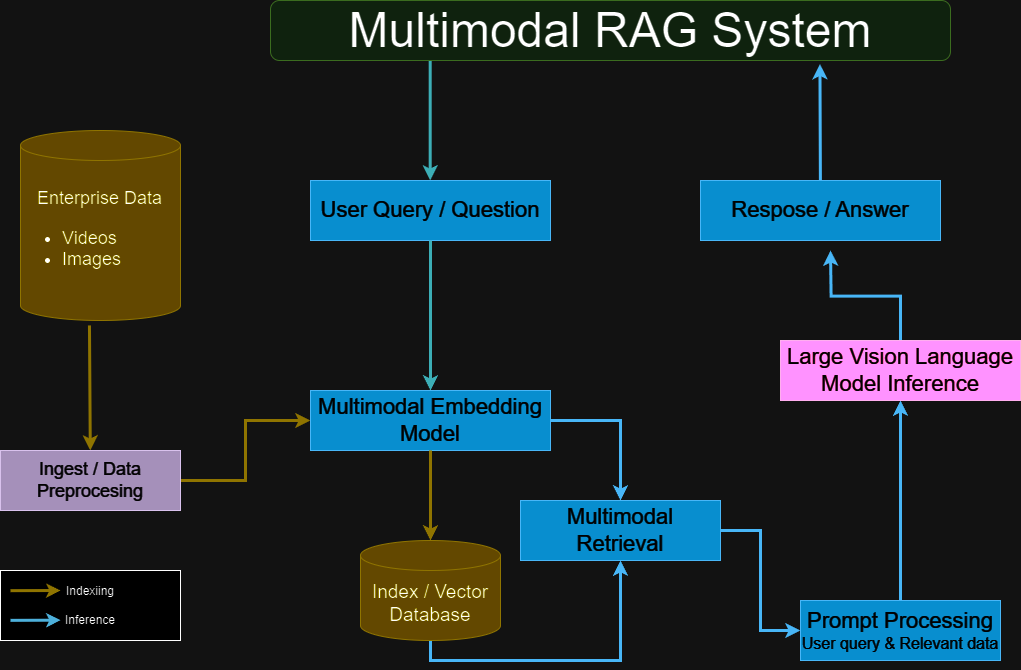

---

# Traditional RAG vs Multimodal RAG

Traditional RAG
- Retrieves only text
- Uses text embeddings
- Text LLM generates answer

Multimodal RAG
- Retrieves text + images + documents
- Uses image and text embeddings
- Vision Language Models understand retrieved images

---

# CLIP (Contrastive Language Image Pretraining)

Developed by OpenAI.

Goal:
Learn a common embedding space for images and text.

Instead of classification, CLIP learns similarity.

Image:
"Dog"

Text:
"A brown dog running"

↓

Both should produce similar vectors.

---

# CLIP Dual Encoder

CLIP has two encoders:

1. Image Encoder
2. Text Encoder

Both generate embeddings of the same dimension (typically 512).

Similarity is computed using cosine similarity.

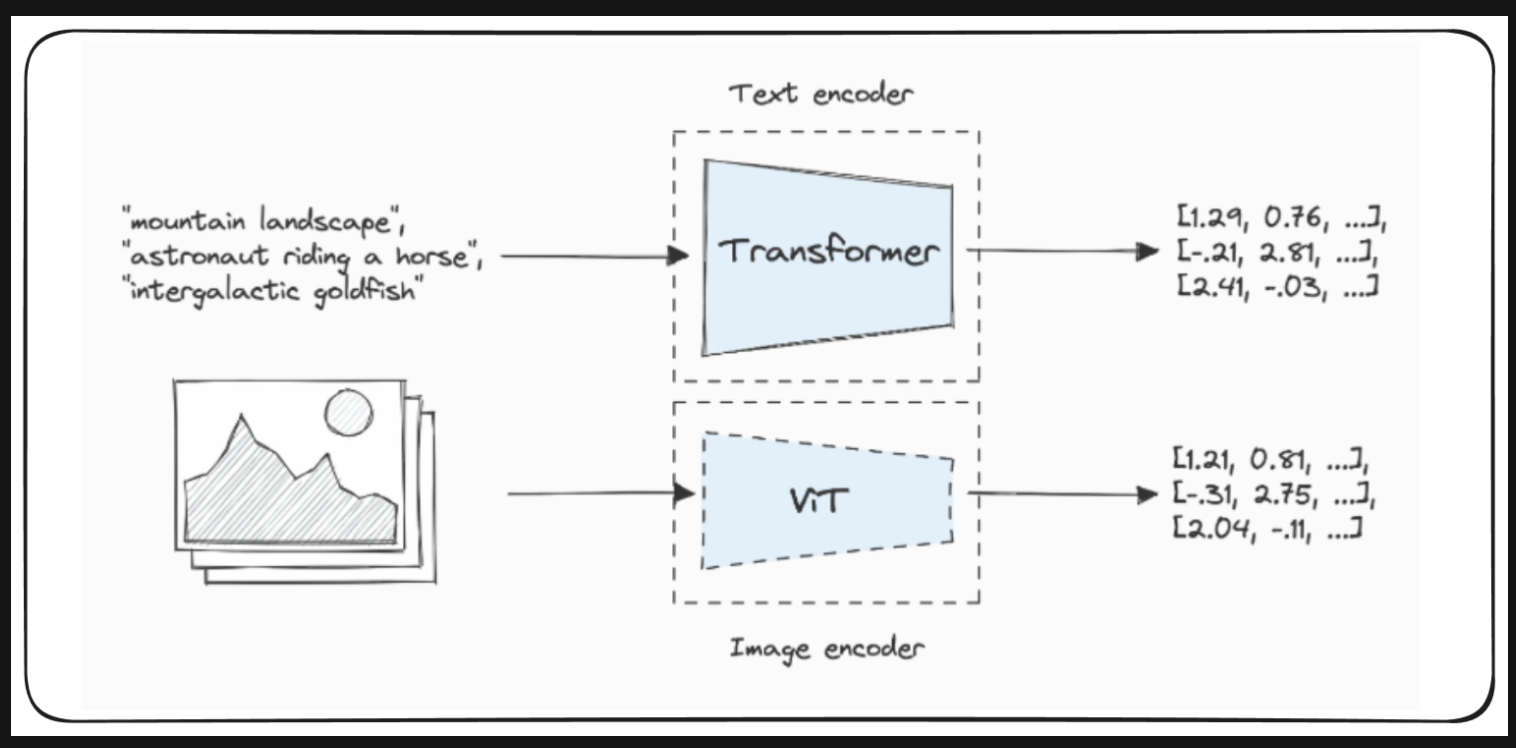

---

# Shared Embedding Space

Image embeddings and text embeddings lie in the same vector space.

Therefore we can perform:

- Text → Image Search
- Image → Text Search
- Image → Image Search
- Text → Text Search

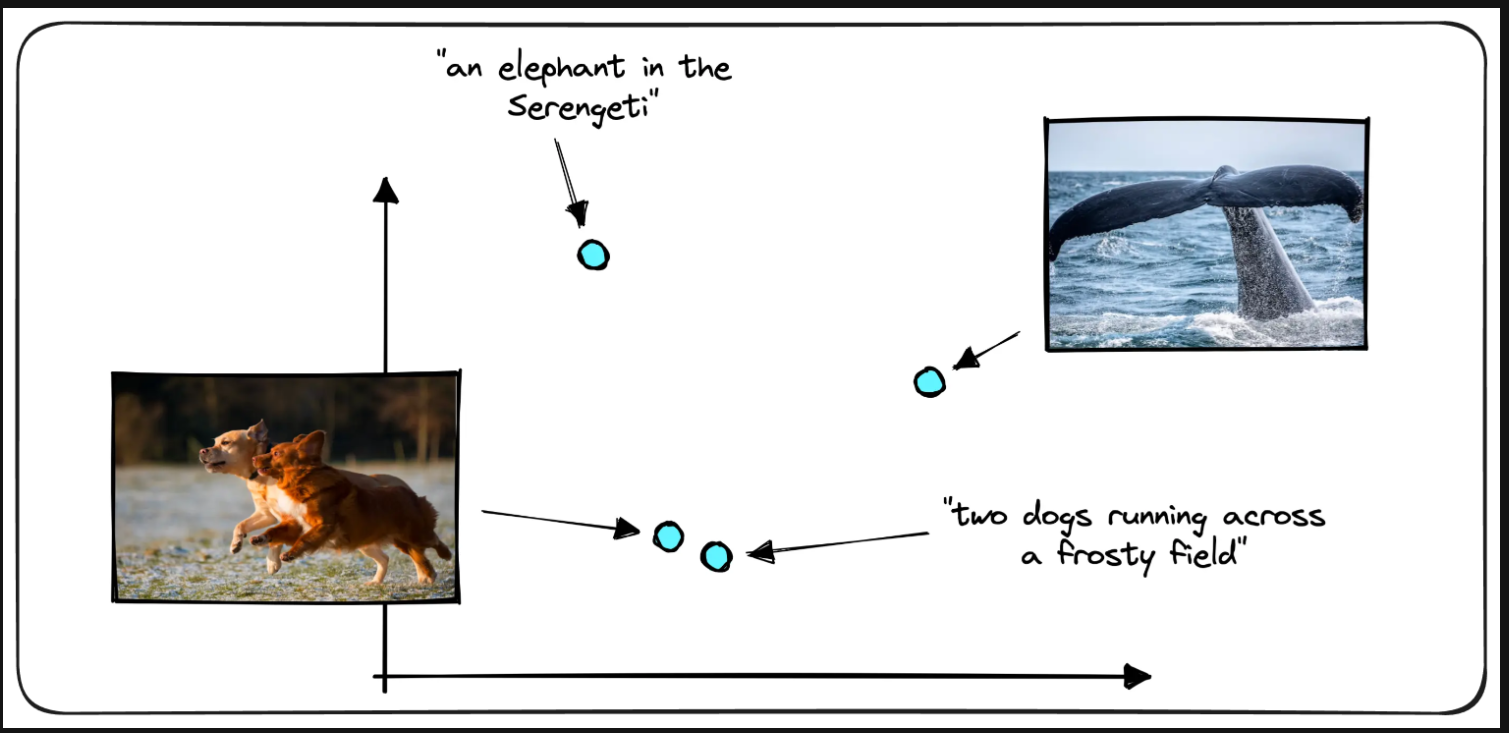

---

# CLIP Pretraining

Training data:
(Image, Caption) pairs

Positive Pair:
Correct image-caption pair

Negative Pair:
Incorrect image-caption pair

Model learns:

Increase similarity:
Correct pairs

Decrease similarity:
Incorrect pairs

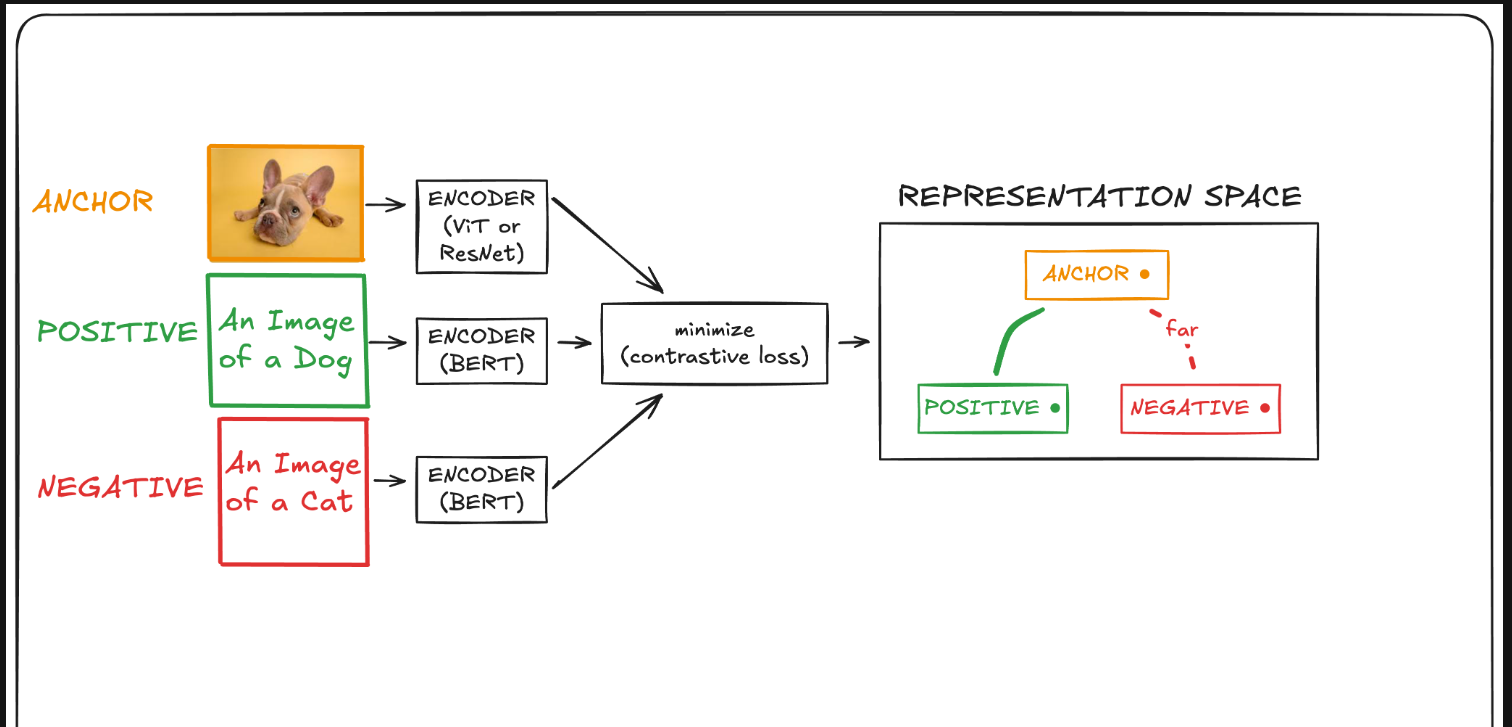

---

# Contrastive Loss

Objective:

Positive pair
→ High similarity

Negative pair
→ Low similarity

Loss is computed in both directions:

Image → Text

Text → Image

Final Loss

= Average(Image Loss, Text Loss)

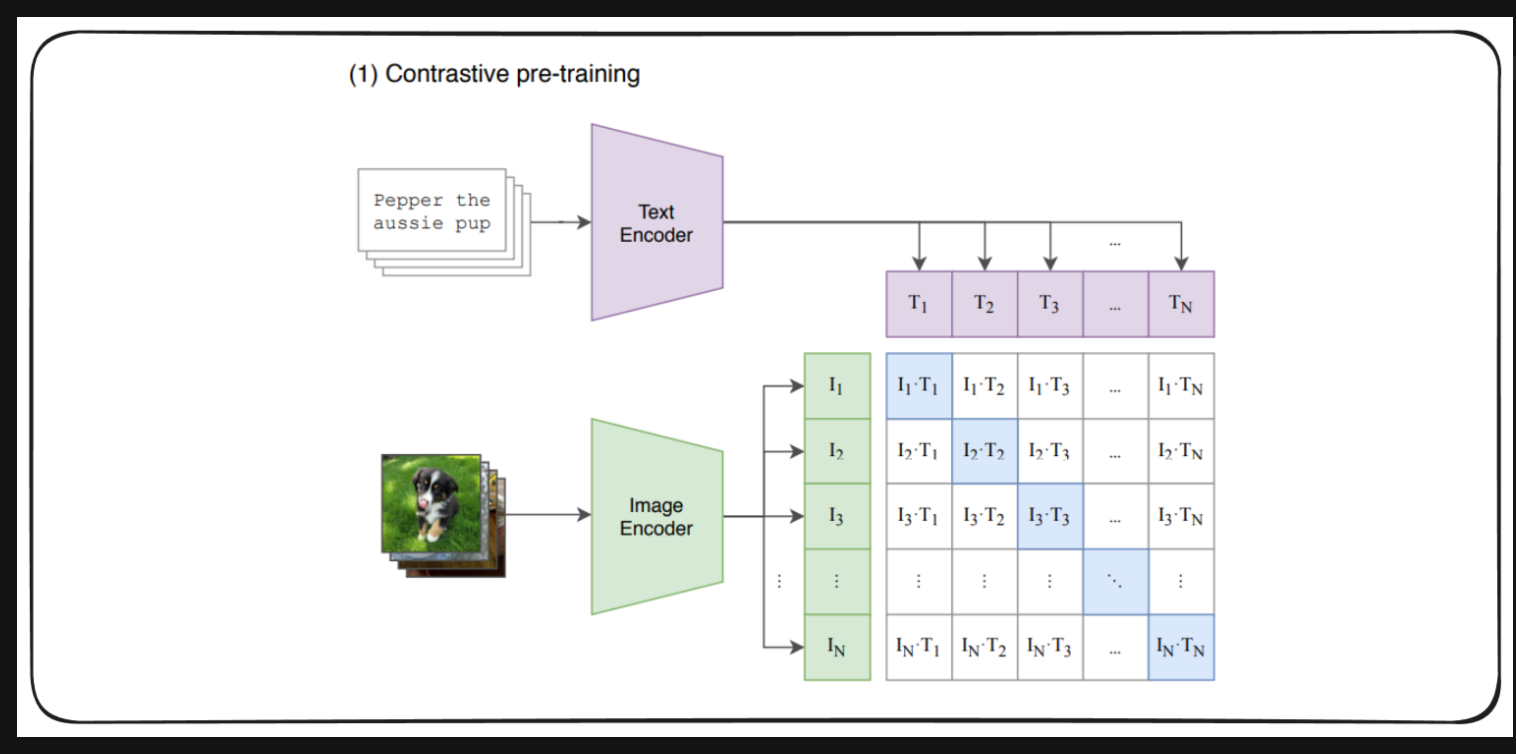

---

# CLIP Architecture

Image
↓

Image Encoder

↓

Projection Layer

↓

Embedding

--------------------------------

Text

↓

Text Encoder

↓

Projection Layer

↓

Embedding

Cosine Similarity compares both embeddings.

---

# Why Projection Layer?

Different encoders produce different feature spaces.

Projection layer maps both into one shared embedding space.

---

# Multimodal Search Pipeline

Text Query

↓

CLIP Text Encoder

↓

Query Embedding

↓

Vector Database

↓

Retrieve nearest image embeddings

↓

Return relevant images

---

# Knowledge Base

Contains:

- Images
- Captions
- Metadata

Each image is converted into embeddings before indexing.

---

# Vector Database

Used for fast similarity search.

Lecture uses:

ChromaDB

Stores:

- Embeddings
- Metadata
- Image paths

---

# Retrieval Workflow

Documents

↓

Generate CLIP Embeddings

↓

Store in ChromaDB

↓

User Query

↓

Generate Query Embedding

↓

Similarity Search

↓

Top-k Results

---

# OpenAI Multimodal RAG

Pipeline:

User Question

↓

Retrieve Images

↓

Send Images + Question to GPT-4o Vision

↓

Generate final response

---

# Components

CLIP
- Generates embeddings

ChromaDB
- Stores vectors

GPT-4o Vision
- Answers using retrieved images

---

# Document RAG

Instead of images, entire PDF pages are indexed.

Examples:
- Manuals
- Books
- Research Papers
- Assembly Instructions

---

# Why Convert PDFs to Images?

Vision models work on images.

Pipeline:

PDF

↓

PDF Pages

↓

Images

↓

Embeddings

↓

Vector Search

---

# ColPali

ColPali is a document retrieval model.

Purpose:

- Encode document pages
- Search semantically
- Retrieve relevant pages

Works directly on document images.

---

# ColPali Workflow

PDF

↓

Convert pages to images

↓

Index using ColPali

↓

Store embeddings

↓

Search

↓

Retrieve relevant pages

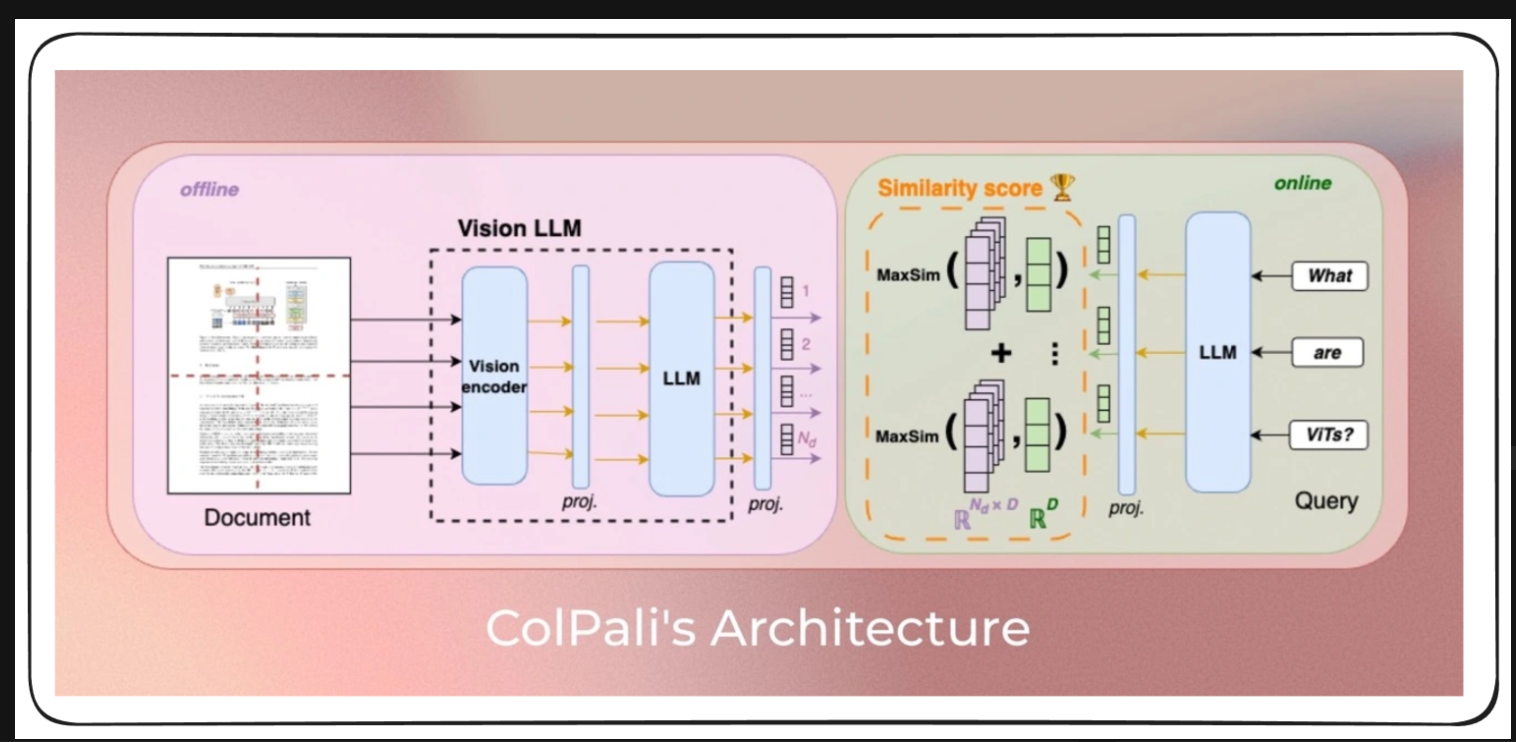

---

# Qwen2-VL

Vision Language Model (VLM)

Input:
- Images
- Text

Output:
- Natural language answer

Used after retrieval.

---

# Complete Document RAG Pipeline

User Query

↓

ColPali Retrieval

↓

Top Relevant Pages

↓

Qwen2-VL

↓

Final Answer

---

# Complete Multimodal RAG Pipeline

Images/Documents

↓

Embedding Model (CLIP/ColPali)

↓

Vector Database

↓

Retrieve Top-k

↓

Vision LLM (GPT-4o/Qwen2-VL)

↓

Answer

---

# Important Models

CLIP
- Image & Text embeddings

ColPali
- Document retrieval

Qwen2-VL
- Vision Language Model

GPT-4o Vision
- Multimodal reasoning

ChromaDB
- Vector database

---

# Advantages

✔ Understands images

✔ Searches visually

✔ Better document QA

✔ Supports manuals & diagrams

✔ More accurate than text-only RAG

---

# Limitations

- Large embedding storage
- Slower indexing
- High GPU requirement
- Retrieval quality depends on embeddings
- VLM inference is expensive

---

# Applications

- Visual Search
- Medical Reports
- Invoice Understanding
- Document QA
- Assembly Manuals
- Educational Content
- E-commerce Image Search

---

# End-to-End Flow

Data

↓

Embeddings

↓

Vector Database

↓

Retriever

↓

Top-k Results

↓

Vision LLM

↓

Final Answer


# Interview Cheat Sheet

---

# CLIP (Contrastive Language–Image Pretraining)

### What is CLIP?
A multimodal model that learns to connect **images** and **text** by placing them into the **same embedding space**.

### Architecture
- Image Encoder
- Text Encoder
- Projection Layers
- Shared Embedding Space

### Similarity
- Uses **Cosine Similarity** to compare image and text embeddings.

### Training
- Uses **Contrastive Learning**.

---

# Shared Embedding Space

Both **image embeddings** and **text embeddings** lie in the **same vector space**.

This enables:

- Text → Image Retrieval
- Image → Text Retrieval
- Image → Image Search
- Text → Text Search

---

# Contrastive Loss

### Goal
- Positive pairs → Similar embeddings
- Negative pairs → Dissimilar embeddings

### Training Objective
Symmetric loss is computed in both directions:

- Image → Text
- Text → Image

This teaches the model to align matching image-text pairs while separating unrelated pairs.

---

# Projection Layer

The outputs of the image encoder and text encoder have different dimensions.

The **Projection Layer** maps both outputs into a **common embedding space**, allowing direct comparison using cosine similarity.

---

# ChromaDB

### Purpose
- Store embeddings
- Fast nearest-neighbor search
- Store metadata
- Retrieve the most similar vectors efficiently

### Used For
- Retrieval-Augmented Generation (RAG)
- Semantic Search
- Image Retrieval
- Document Retrieval

---

# ColPali

### Purpose
A vision-based retrieval model used for document understanding.

### Used For
- PDF page embeddings
- Semantic document retrieval
- Finding relevant pages before passing them to an LLM/VLM

---

# Qwen2-VL

### Type
Vision-Language Model (VLM)

### Input
- Images
- Text

### Output
- Natural language responses
- Visual reasoning
- Image understanding

---

# GPT-4o Vision

### Role
Used **after retrieval**.

### Input
- Retrieved document/page images
- User question

### Output
- Final natural language answer based on the retrieved images

---

# Why Convert PDFs to Images?

Vision-Language Models operate on **images**, not raw PDF files.

Therefore:

```
PDF
   ↓
Convert each page into an image
   ↓
Generate embeddings
   ↓
Store in Vector Database
```

---

# Complete RAG Pipeline

```text
PDF/Documents
        ↓
Convert PDF Pages → Images
        ↓
Generate Embeddings (CLIP / ColPali)
        ↓
Store Embeddings in ChromaDB
        ↓
User Query
        ↓
Generate Query Embedding
        ↓
Nearest Neighbor Search
        ↓
Retrieve Most Relevant Images/Pages
        ↓
Pass Retrieved Images + Question
        ↓
Vision Language Model (Qwen2-VL / GPT-4o Vision)
        ↓
Final Answer
```

---

# One-Line Interview Answers

### What is CLIP?
A multimodal model that learns joint image-text embeddings using contrastive learning.

### Why use a Shared Embedding Space?
So images and text can be directly compared using cosine similarity.

### What is Contrastive Loss?
A loss function that brings matching image-text pairs closer while pushing non-matching pairs apart.

### Why is the Projection Layer needed?
To map outputs from different encoders into the same embedding space.

### Why use ChromaDB?
To efficiently store embeddings and perform fast similarity search.

### What is ColPali used for?
Generating semantic embeddings for document pages and retrieving relevant pages.

### What is Qwen2-VL?
A Vision-Language Model that understands both images and text.

### Why use GPT-4o Vision after retrieval?
To analyze the retrieved images and generate the final answer.

### Why convert PDFs into images?
Because Vision-Language Models process images rather than raw PDF files.

### End-to-End Pipeline
**Data → Embeddings → Vector Database → Retrieval → Vision Language Model → Answer**

# Multimodal RAG Interview Questions & Answers

---

# Easy (1-Line Answers)

### 1. What is Multimodal RAG?
Multimodal RAG retrieves information from multiple data types (text, images, PDFs, etc.) and uses an LLM/VLM to generate accurate answers.

### 2. How is Multimodal RAG different from traditional RAG?
Traditional RAG retrieves only text, while Multimodal RAG retrieves and understands both text and visual data.

### 3. What is CLIP?
CLIP is a dual-encoder model that learns joint image-text embeddings using contrastive learning.

### 4. Why is CLIP called a dual encoder model?
Because it uses separate encoders for images and text.

### 5. What is an embedding?
An embedding is a dense numerical vector representing the semantic meaning of data.

### 6. What is cosine similarity?
Cosine similarity measures how similar two embeddings are by comparing the angle between them.

### 7. Why do image and text embeddings have the same dimension?
So they can be directly compared in the same embedding space.

### 8. What is a shared embedding space?
It is a common vector space where related images and text are placed close together.

### 9. What is contrastive learning?
Contrastive learning trains a model to bring similar pairs closer and push dissimilar pairs apart.

### 10. What is contrastive loss?
Contrastive loss optimizes embeddings so matching pairs are similar and non-matching pairs are different.

---

# Medium (2-Line Answers)

### 1. Why does CLIP require a projection layer?
The image and text encoders produce different feature representations.  
The projection layer maps both into a common embedding space for comparison.

### 2. Explain CLIP training using positive and negative pairs.
Matching image-text pairs are treated as positive examples and are pulled closer together.  
Non-matching pairs are treated as negatives and are pushed farther apart.

### 3. Why is ChromaDB used?
ChromaDB stores embeddings instead of raw data for efficient retrieval.  
It performs fast nearest-neighbor search and stores useful metadata.

### 4. Why are embeddings stored instead of raw images?
Embeddings capture semantic meaning in a compact numerical form.  
This enables fast similarity search without processing the original images repeatedly.

### 5. How does image retrieval work?
The user query is converted into an embedding using the same embedding model.  
The vector database returns the most similar image embeddings based on cosine similarity.

### 6. Why do we retrieve Top-k results?
The single best result may not always contain the complete answer.  
Retrieving multiple relevant results improves accuracy and robustness.

### 7. Why is PDF converted into images?
Vision-language models process images instead of raw PDF files.  
Converting pages into images allows visual understanding and embedding generation.

### 8. What problem does ColPali solve?
ColPali creates semantic embeddings for document pages containing both text and visuals.  
It improves document retrieval accuracy compared to simple OCR-based approaches.

### 9. How does ColPali differ from CLIP?
CLIP is designed for general image-text matching across many domains.  
ColPali is optimized specifically for document retrieval and PDF page understanding.

### 10. What is a Vision Language Model?
A Vision Language Model understands both images and text as input.  
It performs reasoning and generates natural language answers from visual content.

---

# Advanced (3-Line Answers)

### 1. Explain the complete Multimodal RAG pipeline.
Documents are converted into embeddings and stored in a vector database.  
The user's query is embedded and matched against stored vectors to retrieve relevant content.  
The retrieved images or documents are passed to a Vision Language Model to generate the final answer.

### 2. What happens if retrieval returns irrelevant images?
The Vision Language Model receives incorrect context, reducing answer quality.  
This may produce incomplete or inaccurate responses.  
Improving embeddings and retrieval methods helps reduce such errors.

### 3. Why is retrieval necessary before sending data to an LLM?
LLMs cannot efficiently process millions of documents directly.  
Retrieval selects only the most relevant information for the query.  
This reduces cost, improves speed, and increases response accuracy.

### 4. Compare CLIP, ColPali and Qwen2-VL.
CLIP generates shared image-text embeddings for retrieval tasks.  
ColPali specializes in embedding document pages for semantic document search.  
Qwen2-VL is a Vision Language Model that reasons over retrieved images and answers questions.

### 5. Why is cosine similarity preferred over Euclidean distance?
Cosine similarity compares the direction of vectors rather than their magnitude.  
Embeddings often differ in scale but preserve semantic direction.  
This makes cosine similarity more reliable for semantic search.

### 6. How can retrieval accuracy be improved?
Use better embedding models and clean, high-quality data.  
Store meaningful metadata and retrieve multiple relevant results (Top-k).  
Reranking retrieved documents further improves final accuracy.

### 7. What are the limitations of Multimodal RAG?
Performance depends heavily on retrieval quality and embedding accuracy.  
Large image datasets require significant storage and computation.  
Complex visual reasoning can still challenge current Vision Language Models.

### 8. What is the role of metadata in a vector database?
Metadata stores additional information like page number, document name, or source.  
It enables filtering and faster retrieval of relevant results.  
It also helps trace answers back to their original documents.

### 9. How would you scale a Multimodal RAG system to millions of documents?
Use distributed vector databases with approximate nearest-neighbor indexing.  
Partition data across multiple servers and optimize embedding generation pipelines.  
Cache frequent queries and use reranking only on the retrieved subset.

### 10. Explain the end-to-end inference flow from user query to final answer.
The user query is converted into an embedding and matched with stored document embeddings.  
The most relevant images or pages are retrieved from the vector database.  
These are sent to a Vision Language Model, which generates the final natural language answer.